In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
#from sklearn import tree
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score#, confusion_matrix, ConfusionMatrixDisplay
from pickle import load, dump
import seaborn as sns  

In [25]:
data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [26]:
data.shape

(768, 9)

In [27]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [29]:
data['Outcome'].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

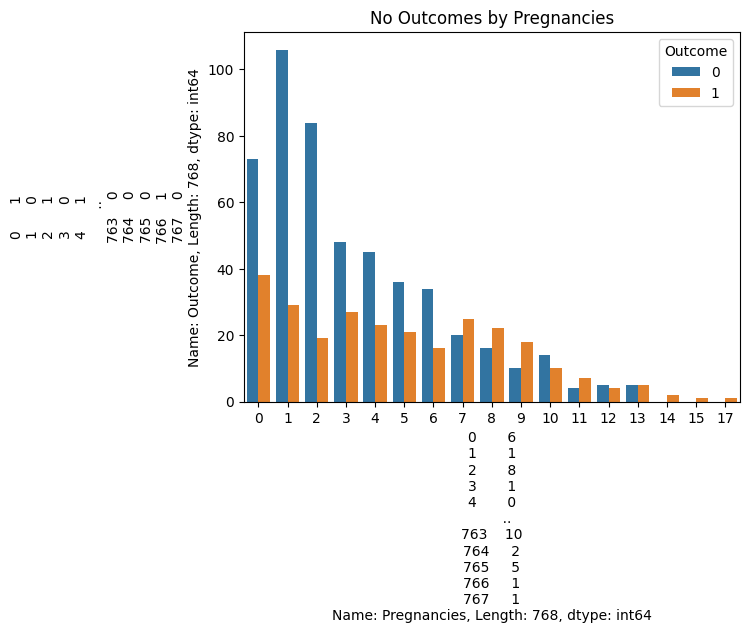

In [30]:
sns.countplot(x='Pregnancies', hue='Outcome', data=data)

# Customize the plot (optional)
plt.title('No Outcomes by Pregnancies')
plt.xlabel(data['Pregnancies'])
plt.ylabel(data['Outcome'])
plt.legend(title='Outcome')
plt.show()

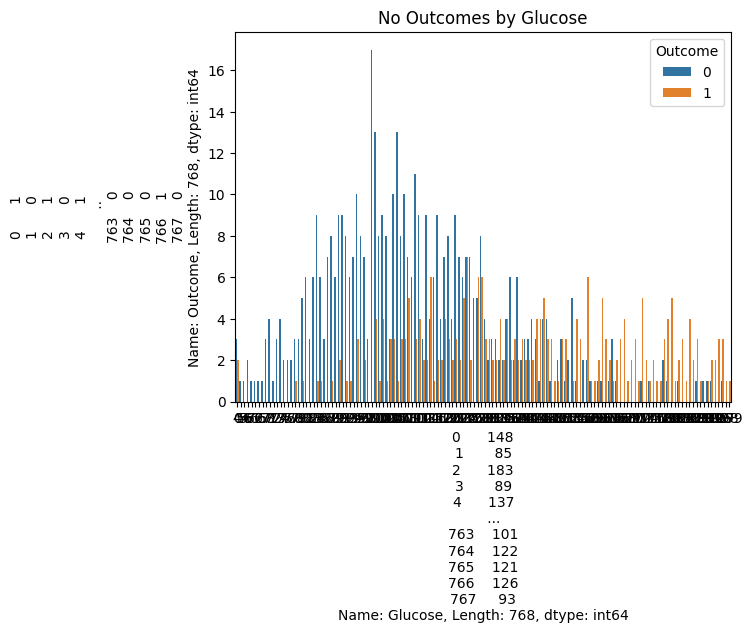

In [31]:
sns.countplot(x='Glucose', hue='Outcome', data=data)

# Customize the plot (optional)
plt.title('No Outcomes by Glucose')
plt.xlabel(data['Glucose'])
plt.ylabel(data['Outcome'])
plt.legend(title='Outcome')
plt.show()

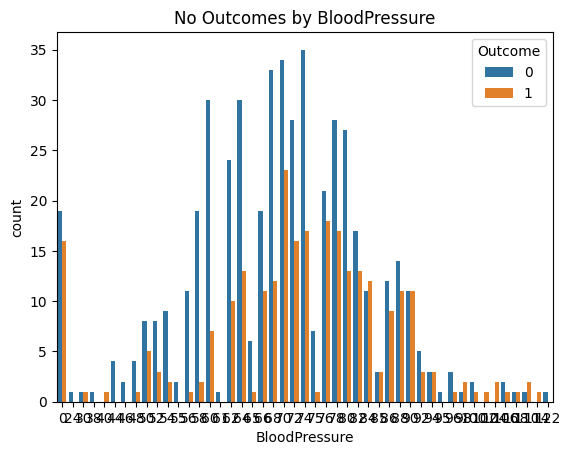

In [32]:
sns.countplot(x='BloodPressure', hue='Outcome', data=data)

# Customize the plot (optional)
plt.title('No Outcomes by BloodPressure')

plt.legend(title='Outcome')
plt.show()

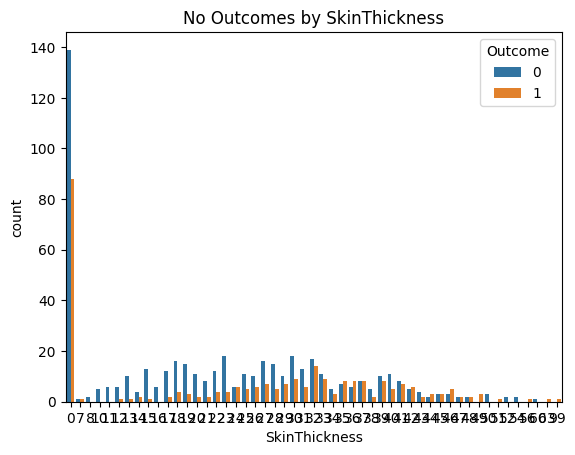

In [33]:
sns.countplot(x='SkinThickness', hue='Outcome', data=data)

# Customize the plot (optional)
plt.title('No Outcomes by SkinThickness')
#plt.xlabel(data['SkinThickness'].head(50))
#plt.ylabel(data['Outcome'].head(50))
plt.legend(title='Outcome')
plt.show()

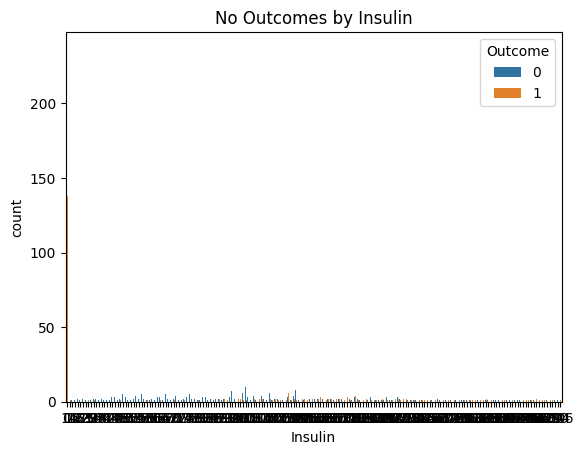

In [34]:
sns.countplot(x='Insulin', hue='Outcome', data=data)

# Customize the plot (optional)
plt.title('No Outcomes by Insulin')
#plt.xlabel(data['Insulin'])
#plt.ylabel(data['Outcome'])
plt.legend(title='Outcome')
plt.show()

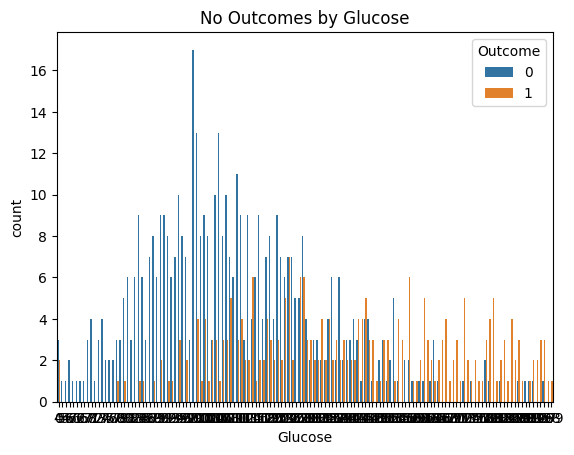

In [35]:
sns.countplot(x='Glucose', hue='Outcome', data=data)
sns.countplot
# Customize the plot (optional)
plt.title('No Outcomes by Glucose')

plt.legend(title='Outcome')
plt.show()

In [36]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [37]:


num_variables = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

# We divide the dataset into training and test samples
X = data.drop("Outcome", axis = 1)[num_variables]
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84,0,0,0,0.0,0.304,21
618,9,112,82,24,0,28.2,1.282,50
346,1,139,46,19,83,28.7,0.654,22
294,0,161,50,0,0,21.9,0.254,65
231,6,134,80,37,370,46.2,0.238,46


<Axes: >

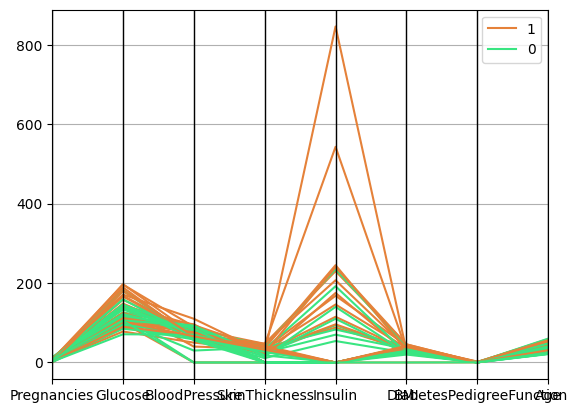

In [38]:


pd.plotting.parallel_coordinates(data.head(50),class_column="Outcome", color = ("#E58139", "#39E581", "#8139E5"))

In [39]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state = 42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

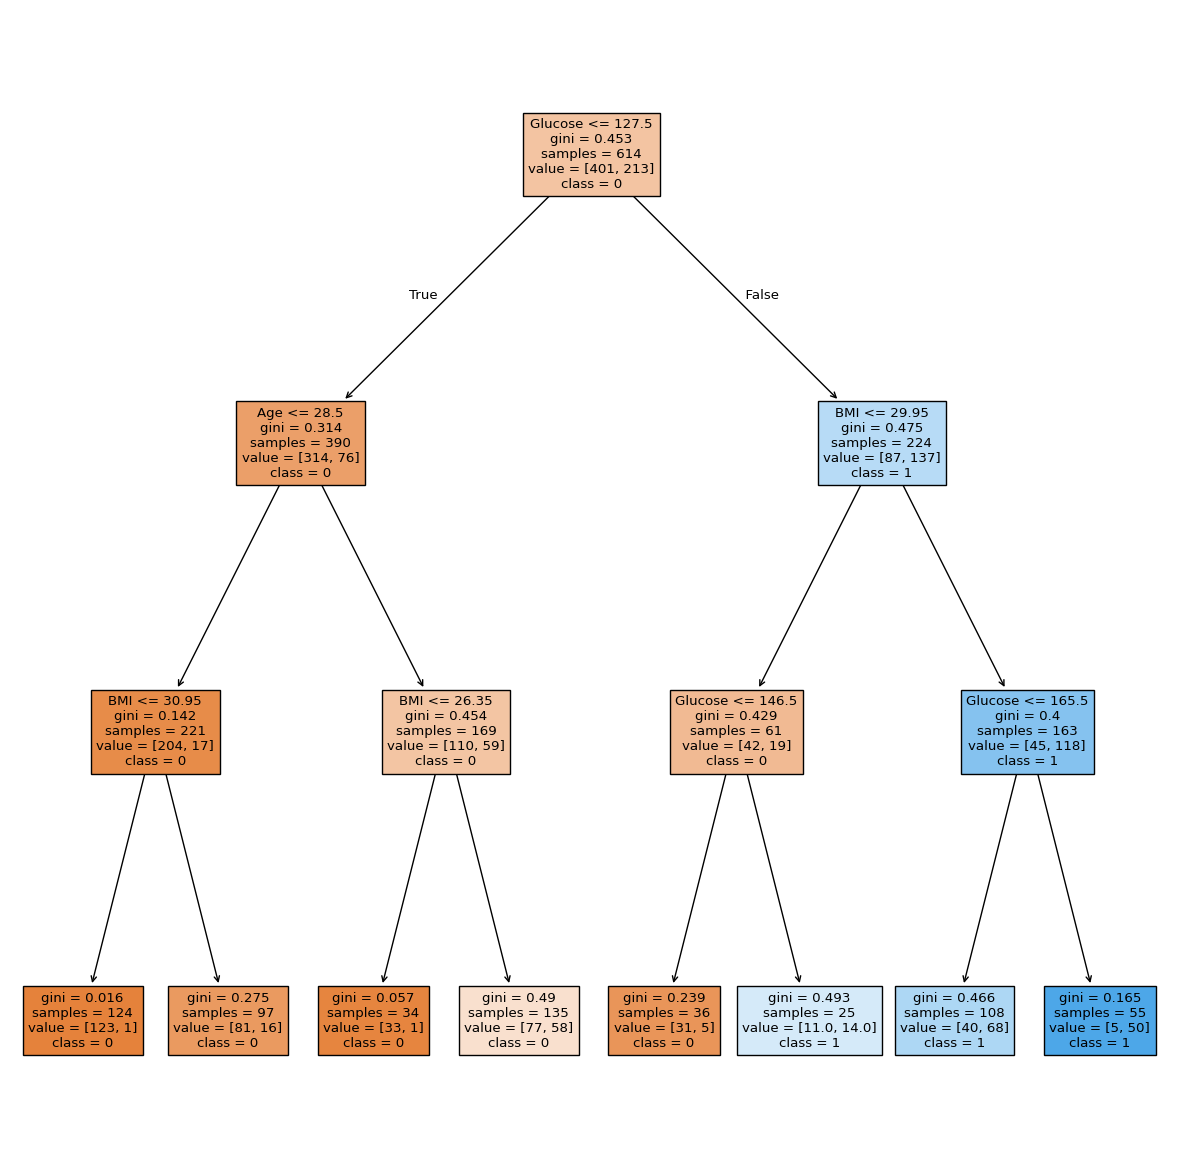

In [40]:
import matplotlib.pyplot as plt
from sklearn import tree

fig = plt.figure(figsize=(15,15))

tree.plot_tree(model, feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)

plt.show()

In [41]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [42]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7597402597402597

In [43]:
from pickle import dump

dump(model, open("decision_tree_classifier_default_42.sav", "wb"))

In [45]:
model = LogisticRegression(max_iter=200)  # Increase max_iter as needed  
model.fit(X_train, y_train)  
y_pred = model.predict(X_test)  

base_accuracy = accuracy_score(y_test, y_pred)  
print(base_accuracy) 

0.7467532467532467


In [46]:
from sklearn.preprocessing import StandardScaler  

# Scale the features  
scaler = StandardScaler()  
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)  

# Fit the model on the scaled data  
model = LogisticRegression(max_iter=200)  # Increase max_iter as needed  
model.fit(X_train_scaled, y_train)  
y_pred = model.predict(X_test_scaled)  

base_accuracy = accuracy_score(y_test, y_pred)  
print(base_accuracy)  

0.7532467532467533


In [47]:
from sklearn.model_selection import GridSearchCV

# We define the parameters that we want to adjust by hand
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

# We initialize the grid
grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 5)
grid

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=200),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [48]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

grid.fit(X_train, y_train)

print(f"Best hyperparameters: {grid.best_params_}")

Best hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'newton-cg'}


In [49]:
model_grid = LogisticRegression(penalty = "l1", C = 10, solver = "liblinear")
model_grid.fit(X_train, y_train)
y_pred = model_grid.predict(X_test)

grid_accuracy = accuracy_score(y_test, y_pred)
grid_accuracy

0.7532467532467533